# Implementing Real-Time Bitcoin Price Analysis with Spark SQL

This notebook shows an example of Real-Time Bitcoin Price Analysing using the Spark SQL. This example will demonstrate:
- Loading data into views in real-time
- Applying basic and complex SQL queries for time-series analysis
    - Aggregation Functions
    - Determining Thresholds
- Creating Time Series plots for visualization

# Getting Set Up - Libraries and Data
First we will load and create view for the price data for the past year at the daily level and the price data for the past 90 days at the hourly level, which will have automatic updates every hour. Data is loaded using the BitcoinDataHandler class which can be found in sparkSQL_utils.py.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [1]:
#Import libraries.
import os
import logging
import pyspark.sql
import sparkSQL_utils
import matplotlib.pyplot as plt
import pandas as pd
import threading
import pyspark.sql.functions as F

In [16]:
#Verify java is installed
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-arm64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]
!echo $JAVA_HOME
!ls $JAVA_HOME/bin


/usr/lib/jvm/java-11-openjdk-arm64
jaotc	   javadoc   jdeprscan	jinfo  jps	   jstatd   rmiregistry
jar	   javap     jdeps	jjs    jrunscript  keytool  serialver
jarsigner  jcmd      jfr	jlink  jshell	   pack200  unpack200
java	   jconsole  jhsdb	jmap   jstack	   rmic
javac	   jdb	     jimage	jmod   jstat	   rmid


In [2]:
#Create the simple Spark session in the notebook.
spark = pyspark.sql.SparkSession.builder \
    .appName("BitcoinPriceAnalysis") \
    .config("spark.sql.legacy.createHiveTableByDefault", "false") \
    .config("spark.sql.session.timeZone", "UTC") \
    .getOrCreate()

#Create & initialize instance of the BitcoinDataHandler class.
handler = sparkSQL_utils.BitcoinDataHandler(spark)

Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/05/06 22:54:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#Load historical price data. This creates the view btc_prices (up to 1 year) at the daily level.
handler.load_data(total_days=365, currency="usd", view_name="btc_prices", data_path="btc_prices_daily")

Cleared view btc_prices.
Fetching Bitcoin data.


Created view btc_prices and updated with 365 rows.


In [4]:
#Create btc_prices_hourly_auto and start the automatic background updates for new data. Data is updated every hour.
thread = threading.Thread(
    target=handler.start_real_time_update,
    kwargs={"curr": "usd", "days": 90, "vw_nm":"btc_prices_hourly_auto", "path":"btc_prices_hourly"}
)
thread.daemon = True
thread.start()

Cleared view btc_prices_hourly_auto.
Fetching Bitcoin data.
Created view btc_prices_hourly_auto and updated with 2159 rows.


In [28]:
#Run to stop real time updates at hourly level.
#handler.stop_real_time_update()

Real-time hourly updates stopped.


In [5]:
#Confirm data is populated in the views.
spark.sql("SELECT * FROM btc_prices ORDER BY price_date DESC LIMIT 5").show()
spark.sql("SELECT * FROM btc_prices_hourly_auto ORDER BY price_date DESC LIMIT 5").show()

+-----------------+-----------+----------+
|            price|  timestamp|price_date|
+-----------------+-----------+----------+
|94326.62048529249|1.7464032E9|2025-05-05|
|95922.86842404422|1.7463168E9|2025-05-04|
| 96855.5681343944|1.7462304E9|2025-05-03|
|96426.94522273027| 1.746144E9|2025-05-02|
|94235.75331048167|1.7460576E9|2025-05-01|
+-----------------+-----------+----------+

+-----------------+----------------+-------------------+
|            price|       timestamp|         price_date|
+-----------------+----------------+-------------------+
|94732.07505209661|1.746471891322E9|2025-05-05 19:04:51|
|94488.70233451825|1.746468351846E9|2025-05-05 18:05:51|
|94207.40183338308|1.746464993544E9|2025-05-05 17:09:53|
|93724.80501461533| 1.74646090048E9|2025-05-05 16:01:40|
|93831.61281503776|1.746457790134E9|2025-05-05 15:09:50|
+-----------------+----------------+-------------------+



In [6]:
spark.sql("SELECT distinct * FROM btc_prices_hourly_auto ORDER BY price_date DESC").show()

+-----------------+----------------+-------------------+
|            price|       timestamp|         price_date|
+-----------------+----------------+-------------------+
|94732.07505209661|1.746471891322E9|2025-05-05 19:04:51|
|94488.70233451825|1.746468351846E9|2025-05-05 18:05:51|
|94207.40183338308|1.746464993544E9|2025-05-05 17:09:53|
|93724.80501461533| 1.74646090048E9|2025-05-05 16:01:40|
|93831.61281503776|1.746457790134E9|2025-05-05 15:09:50|
|94365.43018781069|1.746454166809E9|2025-05-05 14:09:26|
|94280.48803833337|1.746450773495E9|2025-05-05 13:12:53|
| 94088.5057159754| 1.74644669945E9|2025-05-05 12:04:59|
| 94133.1803452243|1.746443098578E9|2025-05-05 11:04:58|
|94588.80144204857|1.746439497927E9|2025-05-05 10:04:57|
| 94552.9528661461| 1.74643588307E9|2025-05-05 09:04:43|
|94736.51570501548|1.746432299631E9|2025-05-05 08:04:59|
|94728.12709624284| 1.74642890761E9|2025-05-05 07:08:27|
|94662.83806875185|1.746425274548E9|2025-05-05 06:07:54|
|94388.68665108354|1.7464217535

In [85]:
spark.sql("SELECT * FROM btc_prices_hourly_auto ORDER BY price_date DESC").show()

+-----------------+----------------+-------------------+
|            price|       timestamp|         price_date|
+-----------------+----------------+-------------------+
|94267.85560462873|1.746475825164E9|2025-05-05 20:10:25|
|94429.61201930426|1.746474946814E9|2025-05-05 19:55:46|
|94732.07505209661|1.746471891322E9|2025-05-05 19:04:51|
|94488.70233451825|1.746468351846E9|2025-05-05 18:05:51|
|94207.40183338308|1.746464993544E9|2025-05-05 17:09:53|
|93724.80501461533| 1.74646090048E9|2025-05-05 16:01:40|
|93831.61281503776|1.746457790134E9|2025-05-05 15:09:50|
|94365.43018781069|1.746454166809E9|2025-05-05 14:09:26|
|94280.48803833337|1.746450773495E9|2025-05-05 13:12:53|
| 94088.5057159754| 1.74644669945E9|2025-05-05 12:04:59|
| 94133.1803452243|1.746443098578E9|2025-05-05 11:04:58|
|94588.80144204857|1.746439497927E9|2025-05-05 10:04:57|
| 94552.9528661461| 1.74643588307E9|2025-05-05 09:04:43|
|94736.51570501548|1.746432299631E9|2025-05-05 08:04:59|
|94728.12709624284| 1.746428907

# Understanding the data available
Next, we will explore the historical daily and real-time hourly data and determine the range, amount, and missing data.

## Price historical data

In [7]:
#Confirm that the view contains the past one year of price data.
spark.sql("""SELECT count(distinct price_date) as num_distinct_dates, 
             MIN(price_date) as erlst_price_dt, 
             MAX(price_date) as ltst_price_dt 
             FROM btc_prices""").show()

#Check how many distinct data points (prices) are available per date.
spark.sql("SELECT distinct count(*) as num_prices_per_day FROM btc_prices GROUP BY price_date").show()

+------------------+--------------+-------------+
|num_distinct_dates|erlst_price_dt|ltst_price_dt|
+------------------+--------------+-------------+
|               365|    2024-05-06|   2025-05-05|
+------------------+--------------+-------------+

+------------------+
|num_prices_per_day|
+------------------+
|                 1|
+------------------+



In [8]:
#Check if there are any missing (null) or zero values.
spark.sql("SELECT * FROM btc_prices where price_date IN (null, 0) or price IN (null, 0)").show()

+-----+---------+----------+
|price|timestamp|price_date|
+-----+---------+----------+
+-----+---------+----------+



## Hourly Real-Time Data

In [9]:
#Confirm that the view contains the past one year of price data.
spark.sql("""SELECT count(distinct DATE_FORMAT(price_date, 'yyyy-MM-DD')) as num_distinct_dates, 
             MIN(price_date) as erlst_price_dt, 
             MAX(price_date) as ltst_price_dt 
             FROM btc_prices_hourly_auto""").show()

#Check how many distinct data points (prices) are available per date.
spark.sql("""SELECT distinct count(price) as num_prices_per_day 
          FROM btc_prices_hourly_auto 
          GROUP BY DATE_FORMAT(price_date, 'yyyy-MM-dd')""").show()

#Check how many distinct data points (prices) are available per date.
spark.sql("""SELECT DATE_FORMAT(price_date, 'yyyy-MM-dd') as formatted_price_date,
             count(*) as num_prices_per_day 
          FROM btc_prices_hourly_auto
          GROUP BY DATE_FORMAT(price_date, 'yyyy-MM-dd')
          HAVING count(price) < 24
          """).show()


+------------------+-------------------+-------------------+
|num_distinct_dates|     erlst_price_dt|      ltst_price_dt|
+------------------+-------------------+-------------------+
|                91|2025-02-04 20:04:02|2025-05-05 19:04:51|
+------------------+-------------------+-------------------+

+------------------+
|num_prices_per_day|
+------------------+
|                 4|
|                23|
|                20|
|                24|
+------------------+

+--------------------+------------------+
|formatted_price_date|num_prices_per_day|
+--------------------+------------------+
|          2025-02-04|                 4|
|          2025-03-06|                23|
|          2025-05-05|                20|
+--------------------+------------------+



# Time-Series Analysis: Prices Over the Past Year
Here, we will use Spark SQL queries and aggregation functions to calculate descriptive statistics for the dataset, and determine if the price of Bitcoin has changed in the past year, by how much, and is the change consistent or oscillating.

In [11]:
#Calculate descriptive statistcs for each month in the past year.
spark.sql("""SELECT mth_yr, AVG(price) as avg_price, 
             MIN(price) as min_price, 
             MAX(price) as max_price,
             MAX(price)-MIN(price) as range_in_price
             FROM (SELECT *,DATE_FORMAT(price_date, 'yyyy-MM') as mth_yr FROM btc_prices)
             GROUP BY mth_yr
             ORDER BY mth_yr
          """).show()

+-------+-----------------+------------------+------------------+------------------+
| mth_yr|        avg_price|         min_price|         max_price|    range_in_price|
+-------+-----------------+------------------+------------------+------------------+
|2024-05|65841.85646458039|60776.972079172134| 71430.29700215145|10653.324922979315|
|2024-06|66053.75856626955| 60317.09697945116| 71184.59943059199|10867.502451140826|
|2024-07|62761.60804689704|  55880.3753776708|  68242.2474440493|12361.872066378492|
|2024-08|60107.96853052593| 53956.26184159744| 65357.52960767435|11401.267766076904|
|2024-09|60210.02872389905| 53923.35611071905| 65934.10709441357|12010.750983694525|
|2024-10|65360.04001652121| 60195.18073772453| 72781.11308158132|12585.932343856795|
|2024-11| 85687.3601419989| 67793.29782704762| 98927.49494553401|31134.197118486394|
|2024-12|98380.90778199892| 92627.28213113277|106074.10723541168|13446.825104278905|
|2025-01|99696.06252905859| 92376.27578346101| 106182.2368201815|

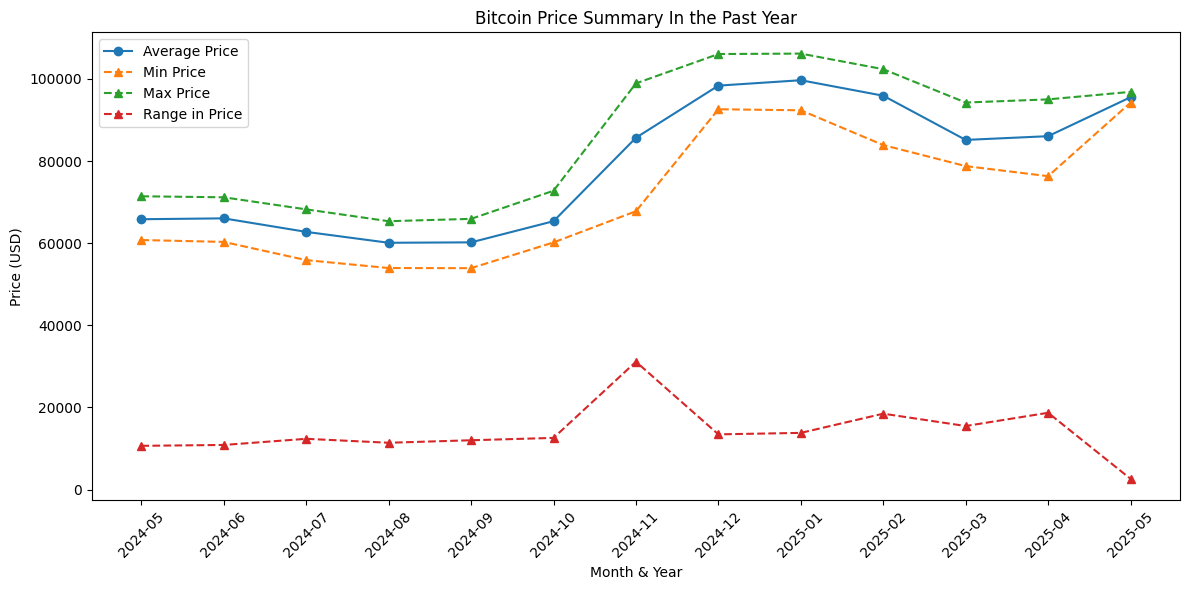

In [13]:
monthly_price_stats_df = spark.sql("""SELECT mth_yr, AVG(price) as avg_price, 
             MIN(price) as min_price, 
             MAX(price) as max_price,
             MAX(price)-MIN(price) as range_in_price
             FROM (SELECT *,DATE_FORMAT(price_date, 'yyyy-MM') as mth_yr FROM btc_prices)
             GROUP BY mth_yr
             ORDER BY mth_yr
          """).toPandas()

#Plot the calculated descriptive statistcs for each month in the past year.
plt.figure(figsize=(12, 6))
plt.plot(monthly_price_stats_df["mth_yr"], monthly_price_stats_df["avg_price"], label="Average Price", marker='o')
plt.plot(monthly_price_stats_df["mth_yr"], monthly_price_stats_df["min_price"], label="Min Price", linestyle='--', marker='^')
plt.plot(monthly_price_stats_df["mth_yr"], monthly_price_stats_df["max_price"], label="Max Price", linestyle='--', marker='^')
plt.plot(monthly_price_stats_df["mth_yr"], monthly_price_stats_df["range_in_price"], label="Range in Price", linestyle='--', marker='^')
plt.xticks(rotation=45)
plt.xlabel("Month & Year")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Price Summary In the Past Year")
plt.legend()
plt.tight_layout()
plt.show()

# Time-Series Analysis: Hourly Prices Over Past 90 Days
Similarly, we will leverage Spark SQL and compute descriptive statistics for the hourly-level dataset and visualize the trend in the Bitcoin prices.

In [14]:
spark.sql("select * from btc_prices_hourly_auto order by price_date desc limit 5").show()

+-----------------+----------------+-------------------+
|            price|       timestamp|         price_date|
+-----------------+----------------+-------------------+
|94732.07505209661|1.746471891322E9|2025-05-05 19:04:51|
|94488.70233451825|1.746468351846E9|2025-05-05 18:05:51|
|94207.40183338308|1.746464993544E9|2025-05-05 17:09:53|
|93724.80501461533| 1.74646090048E9|2025-05-05 16:01:40|
|93831.61281503776|1.746457790134E9|2025-05-05 15:09:50|
+-----------------+----------------+-------------------+



In [15]:
#Calculate descriptive statistcs for each date in the 90 days.
spark.sql("""SELECT date, AVG(price) as avg_price, 
             MIN(price) as min_price, 
             MAX(price) as max_price,
             MAX(price)-MIN(price) as range_in_price
             FROM (SELECT * ,DATE_FORMAT(price_date, 'yyyy-MM-dd') as date FROM btc_prices_hourly_auto)
             GROUP BY date
             ORDER BY date
          """).show()

+----------+-----------------+-----------------+-----------------+------------------+
|      date|        avg_price|        min_price|        max_price|    range_in_price|
+----------+-----------------+-----------------+-----------------+------------------+
|2025-02-04|97727.59116105178| 96386.5143187413|98860.42539595038| 2473.911077209079|
|2025-02-05|97771.20209135517|96439.88149814382|98611.46674060835|2171.5852424645273|
|2025-02-06|97517.26049684682|95967.15004023662| 98975.0605619712|3007.9105217345787|
|2025-02-07|97338.67380747206|95746.87395405429|99606.01843437883|3859.1444803245395|
|2025-02-08|96306.15208987617|95836.79513855922|96786.35922159553| 949.5640830363118|
|2025-02-09|96561.10528505997|95340.48294665758| 97267.4076648532|1926.9247181956307|
|2025-02-10|97208.73992662669|95524.22026320195|98334.08502172824| 2809.864758526295|
|2025-02-11| 97226.1504090253|95017.42507160608| 98467.0013054058|3449.5762337997294|
|2025-02-12|96228.92400591075|94907.03940613412|97917.

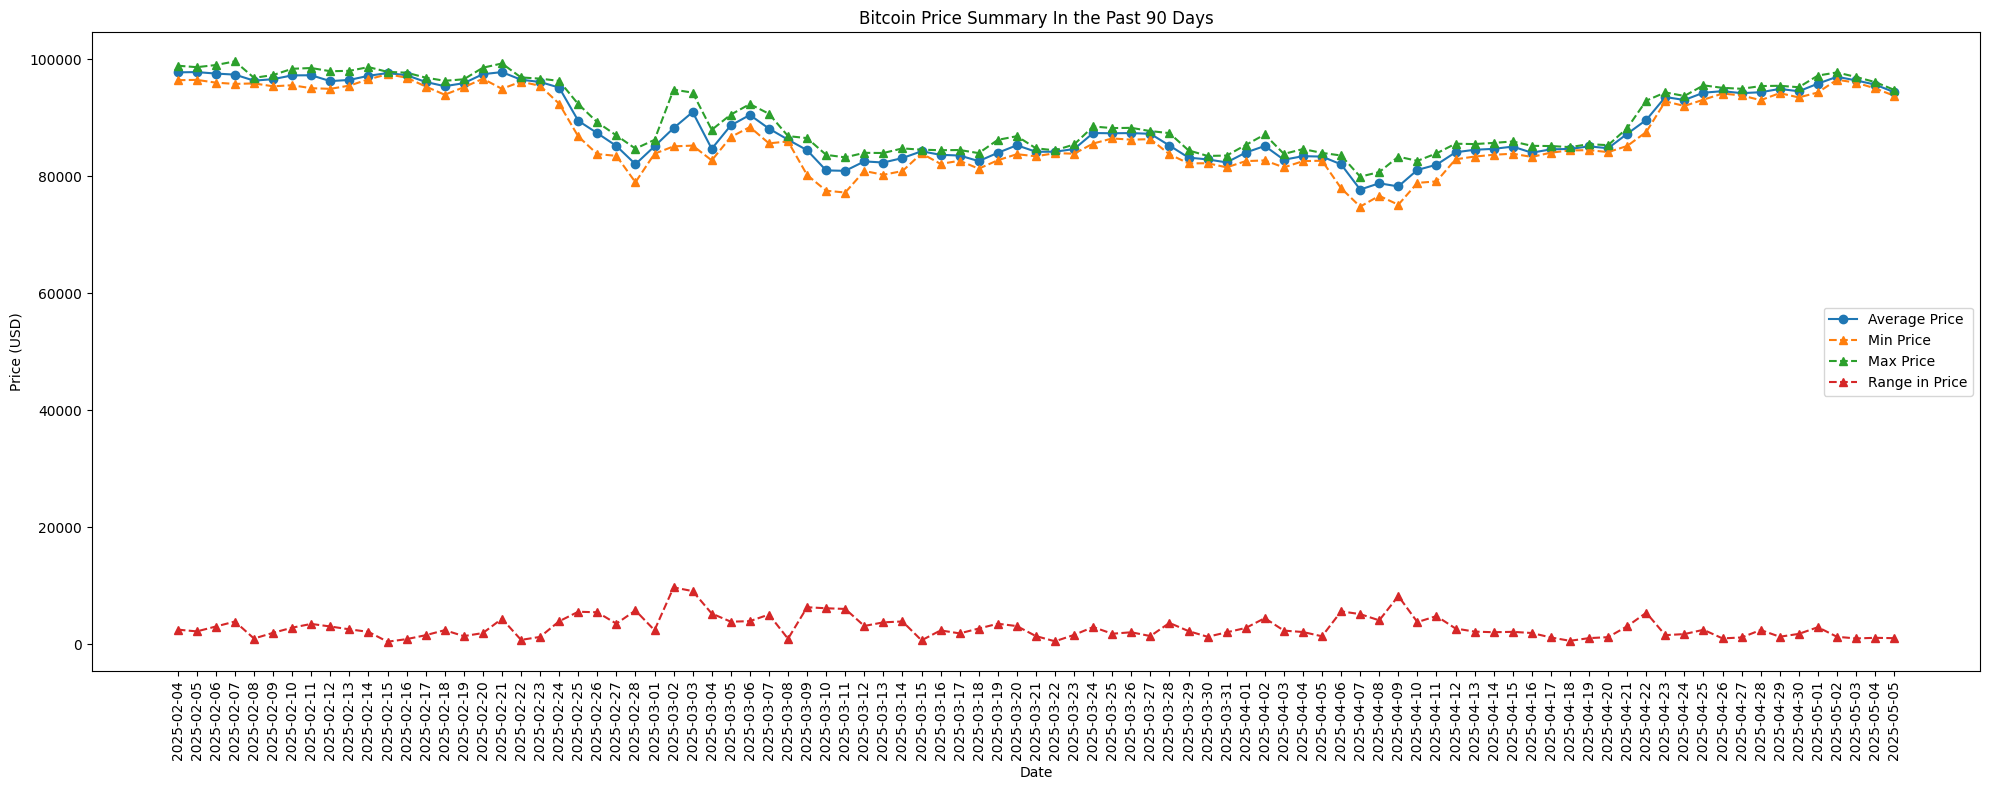

In [16]:
daily_price_stats_df = spark.sql("""SELECT date, AVG(price) as avg_price, 
             MIN(price) as min_price, 
             MAX(price) as max_price,
             MAX(price)-MIN(price) as range_in_price
             FROM (SELECT *,DATE_FORMAT(price_date, 'yyyy-MM-dd') as date FROM btc_prices_hourly_auto)
             GROUP BY date
             ORDER BY date
          """).toPandas()

#Plot the calculated descriptive statistcs for each month in the past year.
plt.figure(figsize=(20, 8))
plt.plot(daily_price_stats_df["date"], daily_price_stats_df["avg_price"], label="Average Price", marker='o')
plt.plot(daily_price_stats_df["date"], daily_price_stats_df["min_price"], label="Min Price", linestyle='--', marker='^')
plt.plot(daily_price_stats_df["date"], daily_price_stats_df["max_price"], label="Max Price", linestyle='--', marker='^')
plt.plot(daily_price_stats_df["date"], daily_price_stats_df["range_in_price"], label="Range in Price", linestyle='--', marker='^')
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Price Summary In the Past 90 Days")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
#Calculate the average range in price on one day.
spark.sql("""SELECT 
             AVG(range_in_price) as avg_range_bitcoin_price
             FROM  
                 (SELECT DATE_FORMAT(price_date, 'yyyy-MM-dd'), 
                         MAX(price)-MIN(price) as range_in_price 
                  FROM btc_prices_hourly_auto
                  GROUP BY DATE_FORMAT(price_date, 'yyyy-MM-dd'))
          """).show()

+-----------------------+
|avg_range_bitcoin_price|
+-----------------------+
|     2845.0463939282236|
+-----------------------+



2845.046393928224


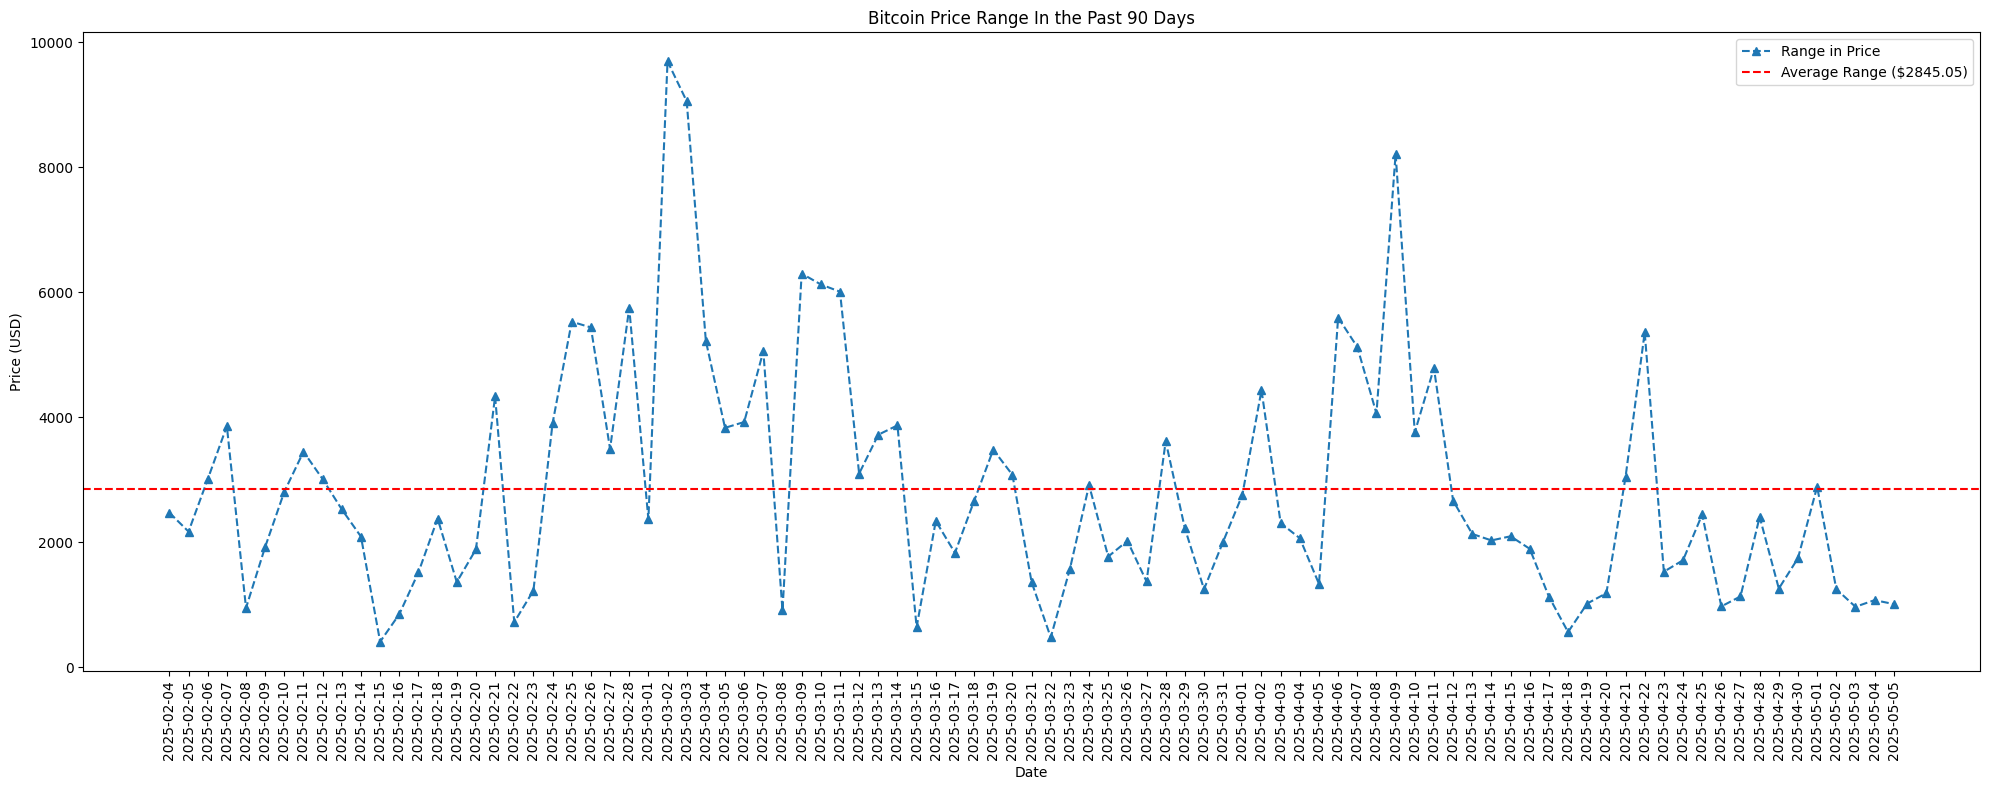

In [17]:
# Calculate average range from above using Dataframe API and create line plot showing the average ranges.
avg_range = daily_price_stats_df['range_in_price'].mean()

#Plot the calculated descriptive statistcs for each day in the time period.
plt.figure(figsize=(20, 8))
plt.plot(daily_price_stats_df["date"], daily_price_stats_df["range_in_price"], label="Range in Price", linestyle='--', marker='^')
plt.axhline(y=avg_range, color='red', linestyle='--', label=f'Average Range (${avg_range:.2f})')
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Price Range In the Past 90 Days")
plt.legend()
plt.tight_layout()
plt.show()

# Anomalies - Spikes/Drops in Past 90 Days
We'll use Spark SQL queries to determine how much the price changes within an hour and if there any anonomalies: spikes or drops as determined by absolute value of average percent of change as a threshold and identifying any outliers using the IQR method. 

## Average Percent Change as a Threshold 

In [19]:
#Query to identify the price and price percent changes at the hourly level.
spark.sql("""SELECT *
             FROM (
                 SELECT *,
                     price - LAG(price) OVER (PARTITION BY DATE_FORMAT(price_date, 'yyyy-MM-dd') ORDER BY price_date) AS price_change,
                     (price - LAG(price) OVER (PARTITION BY DATE_FORMAT(price_date, 'yyyy-MM-dd') ORDER BY price_date)) / LAG(price) OVER (PARTITION BY DATE_FORMAT(price_date, 'yyyy-MM-dd') ORDER BY price_date) * 100 AS percent_change
                 FROM btc_prices_hourly_auto
            )
            ORDER BY price_change desc""").show()

+-----------------+----------------+-------------------+------------------+------------------+
|            price|       timestamp|         price_date|      price_change|    percent_change|
+-----------------+----------------+-------------------+------------------+------------------+
|91378.26201151186|1.740934947716E9|2025-03-02 17:02:27|3932.7189266954665|  4.49733489891073|
|81841.29813646984|1.744221878303E9|2025-04-09 18:04:38|3746.2175800681725| 4.796995602511207|
|94183.67640464348|1.740938497716E9|2025-03-02 18:01:37| 2805.414393131621| 3.070111349653591|
|88065.84191323837|1.741313093352E9|2025-03-07 02:04:53|2475.3754704684543|2.8921158784940313|
| 87445.5430848164|1.740931496774E9|2025-03-02 16:04:56| 2370.352090910106| 2.786184859790545|
|79080.26510244102|1.741658616428E9|2025-03-11 02:03:36|1893.3387875181797|2.4529267816590505|
|83185.92996285958|1.741720114019E9|2025-03-11 19:08:34|1849.7994961297663|2.2742654285556636|
|85454.70850609809|1.741111762346E9|2025-03-04 18:

In [20]:
#Update query from above to also include previous timestamp information, and display percent change.
#Select rows with absolute value of percent change >= absolute value of average percent change in the entire dataset.
spark.sql("""
         WITH formatted_rows as(
             SELECT *, DATE_FORMAT(price_date, 'yyyy-MM-dd') as date
             FROM btc_prices_hourly_auto
         ), previous_ts as (
             SELECT *, LAG(price) OVER (PARTITION BY date ORDER BY price_date) as prev_price,
                       LAG(price_date) OVER (PARTITION BY date ORDER BY price_date) as prev_price_date
             FROM formatted_rows
         ), price_changes as (
             SELECT *, price-prev_price as price_change,
                       (price-prev_price)/prev_price * 100 as percent_change
             FROM previous_ts
         ), avg_change_cte AS (
            SELECT AVG(ABS(percent_change)) AS abs_avg_change_prcnt
            FROM price_changes
         ), final AS (
            SELECT pc.*, ac.abs_avg_change_prcnt
            FROM price_changes pc
            CROSS JOIN avg_change_cte ac
         )
         SELECT price_date, 
                CAST(price as DECIMAL(10,2)), 
                prev_price_date, 
                CAST(prev_price as DECIMAL(10,2)), 
                CAST(price_change as DECIMAL(8,2)), 
                CAST(percent_change as DECIMAL(8,2)), 
                CAST(abs_avg_change_prcnt as DECIMAL(8,2))
         FROM final 
         WHERE abs(percent_change) >= abs_avg_change_prcnt
         ORDER BY abs(percent_change) DESC
         """).show()

+-------------------+--------+-------------------+----------+------------+--------------+--------------------+
|         price_date|   price|    prev_price_date|prev_price|price_change|percent_change|abs_avg_change_prcnt|
+-------------------+--------+-------------------+----------+------------+--------------+--------------------+
|2025-03-07 01:04:38|85590.47|2025-03-07 00:04:45|  89924.21|    -4333.75|         -4.82|                0.36|
|2025-04-09 18:04:38|81841.30|2025-04-09 17:05:55|  78095.08|     3746.22|          4.80|                0.36|
|2025-03-02 17:02:27|91378.26|2025-03-02 16:04:56|  87445.54|     3932.72|          4.50|                0.36|
|2025-03-03 15:09:47|89948.47|2025-03-03 14:00:29|  93288.33|    -3339.86|         -3.58|                0.36|
|2025-03-10 14:08:27|80589.75|2025-03-10 13:04:51|  83263.61|    -2673.86|         -3.21|                0.36|
|2025-03-03 19:09:53|87491.42|2025-03-03 18:00:27|  90362.03|    -2870.61|         -3.18|                0.36|
|

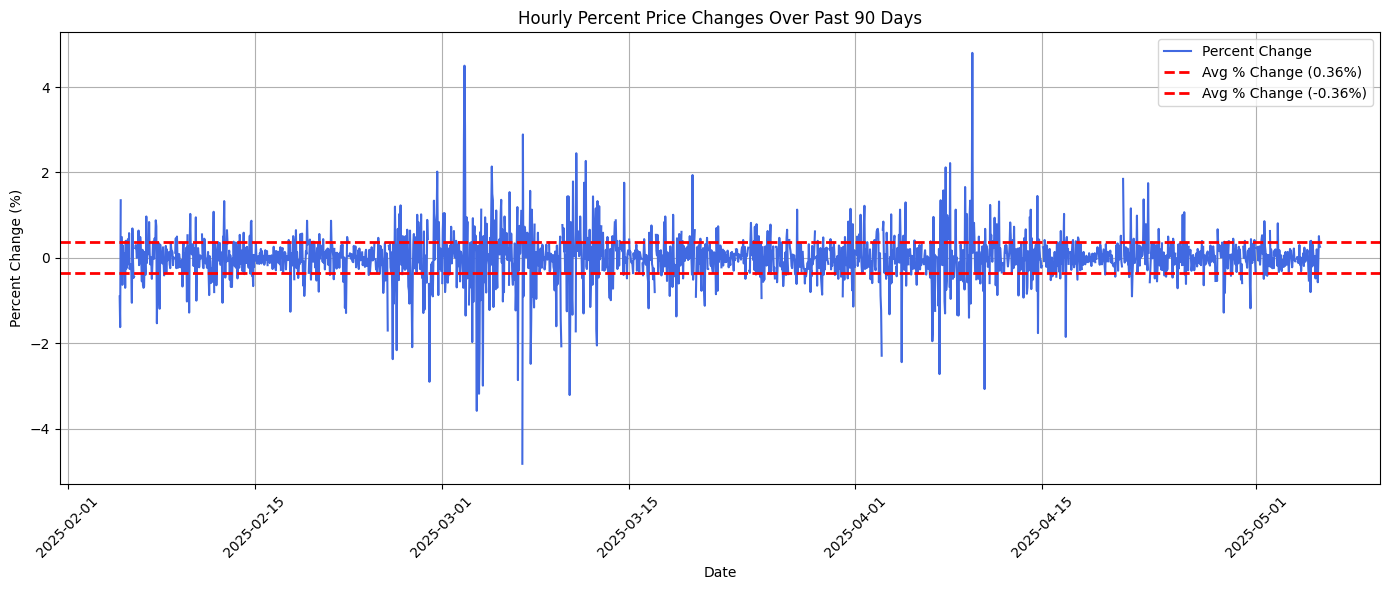

In [23]:
#Use query above, without the average where condition, to visualize the results as a line plot.
query_result = spark.sql("""
    WITH formatted_rows as(
         SELECT *, DATE_FORMAT(price_date, 'yyyy-MM-dd') as date
         FROM btc_prices_hourly_auto
     ), previous_ts as (
         SELECT *, LAG(price) OVER (PARTITION BY date ORDER BY price_date) as prev_price,
                   LAG(price_date) OVER (PARTITION BY date ORDER BY price_date) as prev_price_date
         FROM formatted_rows
     ), price_changes as (
         SELECT *, price-prev_price as price_change,
                   (price-prev_price)/prev_price * 100 as percent_change
         FROM previous_ts
     ), avg_change_cte AS (
        SELECT AVG(ABS(percent_change)) AS abs_avg_change_prcnt
        FROM price_changes
     ), final AS (
        SELECT pc.*, ac.abs_avg_change_prcnt
        FROM price_changes pc
        CROSS JOIN avg_change_cte ac
     )
     SELECT price_date, 
            CAST(percent_change as DECIMAL(8,2)) AS percent_change, 
            CAST(abs_avg_change_prcnt as DECIMAL(8,2)) AS abs_avg_change_prcnt
     FROM final 
     ORDER BY price_date
""").toPandas()

#Convert price date and percent change to correct formats and calculate average percent change.
query_result['price_date'] = pd.to_datetime(query_result['price_date'])
query_result['percent_change'] = pd.to_numeric(query_result['percent_change'], errors='coerce')
avg_change = query_result['percent_change'].abs().mean()

plt.figure(figsize=(14, 6))
plt.plot(query_result['price_date'], query_result['percent_change'], color='royalblue', label='Percent Change', linewidth=1.5)
plt.axhline(avg_change, color='red', linestyle='--', linewidth=2, label=f'Avg % Change ({avg_change:.2f}%)')
plt.axhline(-1*avg_change, color='red', linestyle='--', linewidth=2, label=f'Avg % Change ({-1*avg_change:.2f}%)')

plt.title('Hourly Percent Price Changes Over Past 90 Days')
plt.xlabel('Date')
plt.ylabel('Percent Change (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Implementing IQR on Percent Change as a Threshold 

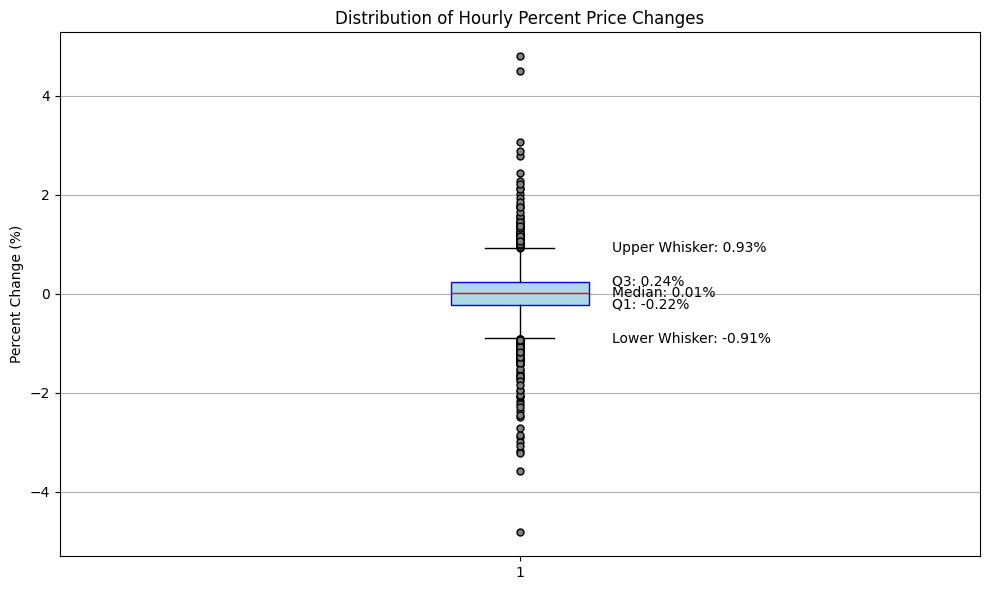

In [24]:
#Calculate the box plot statistics and display the box plot for percent change.
percent_changes = pd.to_numeric(query_result['percent_change'], errors='coerce').dropna()

Q1 = percent_changes.quantile(0.25)
Q2 = percent_changes.median()
Q3 = percent_changes.quantile(0.75)
IQR = Q3 - Q1
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

plt.figure(figsize=(10, 6))
plt.boxplot(percent_changes, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'),
            flierprops=dict(markerfacecolor='gray', markersize=5)
           )

plt.title("Distribution of Hourly Percent Price Changes")
plt.ylabel("Percent Change (%)")
plt.grid(axis='y')

plt.text(1.1, Q1, f"Q1: {Q1:.2f}%", va='center')
plt.text(1.1, Q2, f"Median: {Q2:.2f}%", va='center')
plt.text(1.1, Q3, f"Q3: {Q3:.2f}%", va='center')
plt.text(1.1, lower_whisker, f"Lower Whisker: {lower_whisker:.2f}%", va='center')
plt.text(1.1, upper_whisker, f"Upper Whisker: {upper_whisker:.2f}%", va='center')

plt.tight_layout()
plt.show()


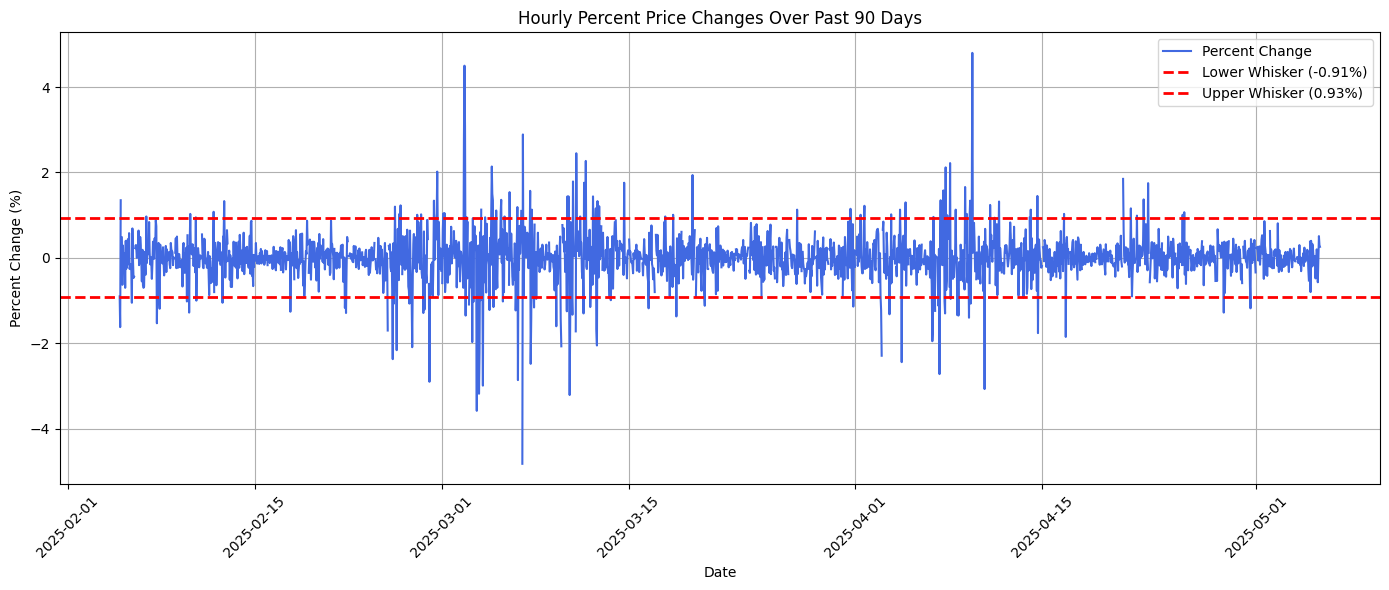

In [25]:
#Plot the same percent price changes using the query, but highlight the whisker bounds calculated above.
plt.figure(figsize=(14, 6))
plt.plot(query_result['price_date'], query_result['percent_change'], color='royalblue', label='Percent Change', linewidth=1.5)
plt.axhline(lower_whisker, color='red', linestyle='--', linewidth=2, label=f'Lower Whisker ({lower_whisker:.2f}%)')
plt.axhline(upper_whisker, color='red', linestyle='--', linewidth=2, label=f'Upper Whisker ({upper_whisker:.2f}%)')

plt.title('Hourly Percent Price Changes Over Past 90 Days')
plt.xlabel('Date')
plt.ylabel('Percent Change (%)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
#Display the price and dates that are considered as outliers using IQR.
outliers_df = query_result[
    (query_result["percent_change"] < lower_whisker) |
    (query_result["percent_change"] > upper_whisker)
]
print(outliers_df)


              price_date  percent_change abs_avg_change_prcnt
2    2025-02-04 22:04:10           -1.62                 0.36
3    2025-02-04 23:01:55            1.35                 0.36
23   2025-02-05 19:04:09           -1.05                 0.36
49   2025-02-06 21:03:56            0.97                 0.36
68   2025-02-07 16:04:13           -1.53                 0.36
...                  ...             ...                  ...
1849 2025-04-22 22:04:55            1.75                 0.36
1911 2025-04-25 12:09:31            1.01                 0.36
1914 2025-04-25 15:04:54            1.07                 0.36
1985 2025-04-28 14:04:48           -1.28                 0.36
2033 2025-04-30 14:09:36           -1.18                 0.36

[170 rows x 3 columns]


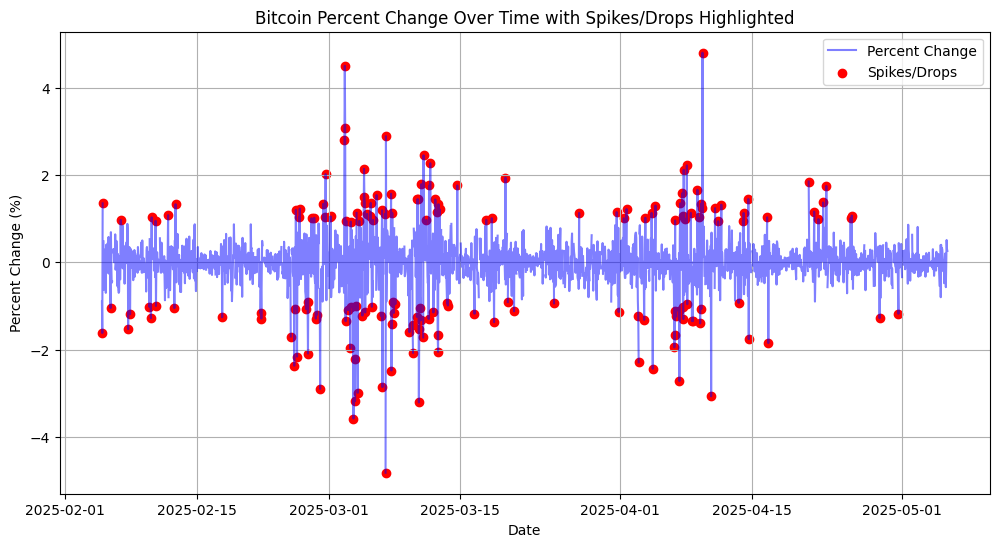

In [39]:
#Highlight those spikes and drops on the earlier figure.
plt.figure(figsize=(12, 6))
plt.plot(query_result['price_date'], query_result['percent_change'], label='Percent Change', color='blue', alpha=0.5)
plt.scatter(outliers_df['price_date'], outliers_df['percent_change'], color='red', label='Spikes/Drops')
plt.title("Bitcoin Percent Change Over Time with Spikes/Drops Highlighted")
plt.xlabel("Date")
plt.ylabel("Percent Change (%)")
plt.legend()
plt.grid(True)
plt.show()


## Further Analysis on 'Signficant' Spikes/Drops

In [80]:
#Create a view with Spikes/Drops identified using IQR and assign a label of Spike or Drop.
spark.sql(f"""
    CREATE OR REPLACE TEMP VIEW spikes_drops_vw AS
    SELECT *
    FROM (
        WITH formatted_rows AS (
            SELECT *, DATE_FORMAT(price_date, 'yyyy-MM-dd') AS date
            FROM btc_prices_hourly_auto
        ), previous_ts AS (
            SELECT *, 
                   LAG(price) OVER (PARTITION BY date ORDER BY price_date) AS prev_price,
                   LAG(price_date) OVER (PARTITION BY date ORDER BY price_date) AS prev_price_date
            FROM formatted_rows
        ), price_changes AS (
            SELECT *, 
                   price - prev_price AS price_change,
                   (price - prev_price) / prev_price * 100 AS percent_change
            FROM previous_ts
        )
        SELECT price_date, 
               CAST(price AS DECIMAL(10,2)) AS price, 
               prev_price_date, 
               CAST(prev_price AS DECIMAL(10,2)) AS prev_price, 
               CAST(price_change AS DECIMAL(8,2)) AS price_change, 
               CAST(percent_change AS DECIMAL(8,2)) AS percent_change, 
               CASE WHEN percent_change < 0 THEN 'DROP' ELSE 'SPIKE' END AS category
        FROM price_changes
    ) t
    WHERE ABS(percent_change) < {lower_whisker} OR ABS(percent_change) > {upper_whisker}
""").show()

++
||
++
++



In [81]:
spark.sql("SELECT * FROM spikes_drops_vw").show()

+-------------------+--------+-------------------+----------+------------+--------------+--------+
|         price_date|   price|    prev_price_date|prev_price|price_change|percent_change|category|
+-------------------+--------+-------------------+----------+------------+--------------+--------+
|2025-02-04 22:04:10|96386.51|2025-02-04 21:08:44|  97972.81|    -1586.29|         -1.62|    DROP|
|2025-02-04 23:01:55|97690.62|2025-02-04 22:04:10|  96386.51|     1304.10|          1.35|   SPIKE|
|2025-02-05 19:04:09|96709.74|2025-02-05 18:04:04|  97736.30|    -1026.56|         -1.05|    DROP|
|2025-02-06 21:03:56|96900.67|2025-02-06 20:04:01|  95967.15|      933.52|          0.97|   SPIKE|
|2025-02-07 16:04:13|98081.81|2025-02-07 15:03:09|  99606.02|    -1524.21|         -1.53|    DROP|
|2025-02-07 21:03:42|95746.87|2025-02-07 20:04:14|  96896.29|    -1149.42|         -1.19|    DROP|
|2025-02-09 22:03:52|95340.48|2025-02-09 21:03:53|  96325.26|     -984.78|         -1.02|    DROP|
|2025-02-1

In [82]:
#Compute some statistics on the absolute percent changed grouped by spike or drop.
spark.sql("""
    SELECT category, 
           MIN(abs(percent_change)) as min_abs_pct_chng,
           MAX(abs(percent_change)) as max_abs_pct_chng,
           AVG(abs(percent_change)) as avg_abs_pct_chng,
           COUNT(*) as num
    FROM spikes_drops_vw
    GROUP BY category
""").show()

+--------+----------------+----------------+----------------+---+
|category|min_abs_pct_chng|max_abs_pct_chng|avg_abs_pct_chng|num|
+--------+----------------+----------------+----------------+---+
|    DROP|            0.93|            4.82|        1.593537| 82|
|   SPIKE|            0.93|            4.80|        1.430000| 85|
+--------+----------------+----------------+----------------+---+



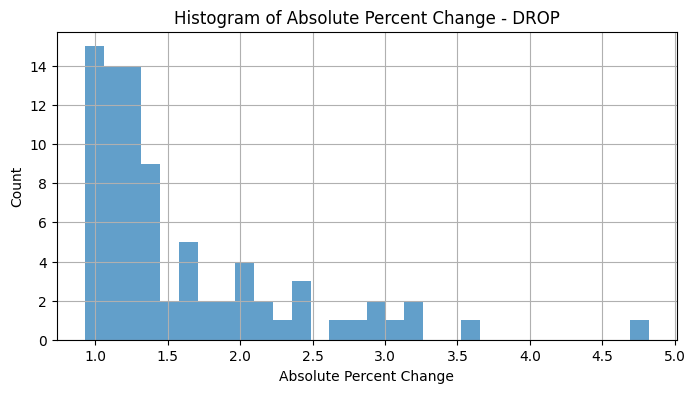

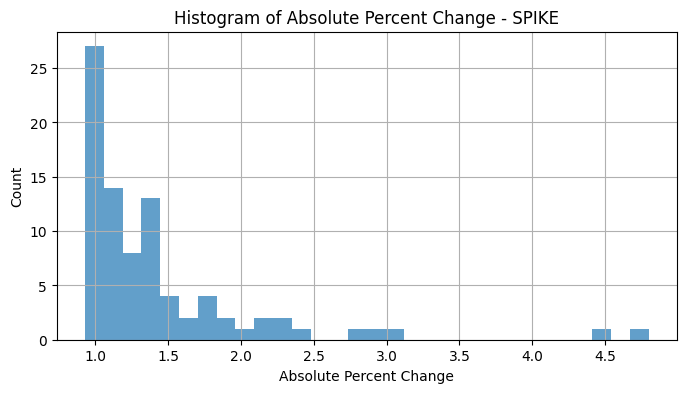

In [84]:
#Understand the distribution of the signficant price changes grouped by spike or drop.
abs_df = spark.sql("""
    SELECT category, abs(percent_change) AS abs_percent_change
    FROM spikes_drops_vw
""").toPandas()

for cat in categories:
    plt.figure(figsize=(8, 4))
    values = abs_df[abs_df['category'] == cat]['abs_percent_change']
    plt.hist(values, bins=bins, alpha=0.7)
    plt.title(f"Histogram of Absolute Percent Change - {cat}")
    plt.xlabel("Absolute Percent Change")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# Price Prediction

## For the next hour 

## For the next day 